In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def column_stats(df, column_name, n=None):
    if n is None:
        n = df.shape[0]
    count_column_name = column_name + "_count"
    count_df = pd.DataFrame(df[column_name].value_counts()).reset_index()
    count_df.columns=[column_name, count_column_name]
    count_df[column_name + "_percent"] = count_df[count_column_name].apply(lambda x: int(x)/n*100)
    print(f"Number of unique values = {len(df[column_name].unique())}")
    print(f"{count_df}")
    return count_df
    
def filter_with_threshold_percentage(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}")
    if n is None:
        n = df.shape[0]
    print(f"n= {n}")
    count_df = column_stats(df, column_name, n=n)
    percent_column_name = column_name + "_percent"
    filtered_count_df = count_df[count_df[percent_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [3]:
def filter_with_threshold_count(df, column_name, threshold, n=None):
    print(f"Size of df = {df.shape}")
    n = df.shape[0]
    count_df = column_stats(df, column_name, n=n)
    count_column_name = column_name + "_count"
    filtered_count_df = count_df[count_df[count_column_name] >= threshold]
    filtered_df = df[df[column_name].isin(list(filtered_count_df[column_name].values))]
    print(f"Size of filtered df = {filtered_df.shape}")
    column_stats(filtered_df, column_name, n=n)
    return filtered_df

In [4]:
def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"])
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

# UniRef90 - EMBL mapping Dataset Generation


In [59]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host.csv")
df = pd.read_csv(file_path)
print(df.shape)
column_stats(df, "virus_name_genus")
column_stats(df, "virus_host_name")

(463755, 11)
Number of unique values = 1490
           virus_name_genus  virus_name_genus_count  virus_name_genus_percent
0                Lentivirus                  223591                 48.213173
1               Hepacivirus                   12619                  2.721049
2         Orthohepadnavirus                   10268                  2.214100
3              Pandoravirus                    4734                  1.020798
4          Alphabaculovirus                    4087                  0.881284
...                     ...                     ...                       ...
1484             Avisivirus                       1                  0.000216
1485         Siniperhavirus                       1                  0.000216
1486           Dianthovirus                       1                  0.000216
1487            Inibicvirus                       1                  0.000216
1488  Epsilonscleroulivirus                       1                  0.000216

[1489 rows x 3 colu

,virus_host_name,virus_host_name_count,virus_host_name_percent
0,Homo sapiens,267599,57.702666
1,Acanthamoeba sp.,7452,1.606883
2,Escherichia coli,4948,1.066943
3,Acanthamoeba castellanii,3952,0.852174
4,Vermamoeba vermiformis,3546,0.764628
...,...,...,...
4520,Cardinalis cardinalis,1,0.000216
4521,Epinephelus tauvina,1,0.000216
4522,Corvus ossifragus,1,0.000216
4523,Nothrus palustris,1,0.000216


### uniref90_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq.csv

In [9]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq.csv")

In [10]:
df = pd.read_csv(file_path)
df["seq_len"] = df["seq"].apply(lambda x: len(x))

In [11]:
df.shape

(303711, 13)

### Deduplicate: Remove duplicates, retain the first occurence
#### TODO: Investigate the presence of 5 duplicate records

In [12]:
df = df[~df.duplicated()]

In [13]:
print("df size = ", df.shape)
df.head()

df size =  (303701, 13)


,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,tax_id_genus,virus_name_genus,seq,seq_len
0,UniRef90_A0A386AT53,151340,AYC54495.1,['Homo sapiens'],Homo sapiens,Papillomaviridae,family,9606,species,NaN,NaN,MDTLSERFNALQENLMDIYESGRDDIETQIMHWQYLRQEQVLFYFA...,442
1,UniRef90_D6NXI8,11676,ADF86160.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species,11646.0,Lentivirus,MAGRSGDSDEELLRVVRIIKQIYQSNPPPNPEGTRQARRNRRRRWR...,116
2,UniRef90_A0A023HQ45,10941,AGO66954.2,['Homo sapiens; sex: M; age: 7 months'],Homo sapiens,Human rotavirus A,no rank,9606,species,10912.0,Rotavirus,MYGIEYTTILIFLISIILLNYILKSVTQMMDYIIYRSLLXXXXXXX...,326
3,UniRef90_A0A291S2S0,42789,ATL73909.1,['Homo sapiens'],Homo sapiens,enterovirus D68,serotype,9606,species,12059.0,Enterovirus,VSETIAENFLSRAALESKRRFEYKDHTSSAGQADKNSFKWTINTRS...,100
4,UniRef90_L0BZL1,11676,AFZ96186.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species,11646.0,Lentivirus,EXEKEGKISKIGPENPYNTPIFAIKKKDSTKWRKLVDFRELNKRTQ...,199


### Remove records without virus genus name

In [22]:
df = df[~df["tax_id_genus"].isna()]
df

,uniref90_id,tax_id,embl_ref_id,embl_host_name,virus_host_name,virus_name,virus_taxon_rank,virus_host_tax_id,virus_host_taxon_rank,tax_id_genus,virus_name_genus,seq,seq_len
1,UniRef90_D6NXI8,11676,ADF86160.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species,11646.0,Lentivirus,MAGRSGDSDEELLRVVRIIKQIYQSNPPPNPEGTRQARRNRRRRWR...,116
2,UniRef90_A0A023HQ45,10941,AGO66954.2,['Homo sapiens; sex: M; age: 7 months'],Homo sapiens,Human rotavirus A,no rank,9606,species,10912.0,Rotavirus,MYGIEYTTILIFLISIILLNYILKSVTQMMDYIIYRSLLXXXXXXX...,326
3,UniRef90_A0A291S2S0,42789,ATL73909.1,['Homo sapiens'],Homo sapiens,enterovirus D68,serotype,9606,species,12059.0,Enterovirus,VSETIAENFLSRAALESKRRFEYKDHTSSAGQADKNSFKWTINTRS...,100
4,UniRef90_L0BZL1,11676,AFZ96186.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species,11646.0,Lentivirus,EXEKEGKISKIGPENPYNTPIFAIKKKDSTKWRKLVDFRELNKRTQ...,199
6,UniRef90_D6NXI9,11676,ADF86161.1,['Homo sapiens'],Homo sapiens,Human immunodeficiency virus 1,species,9606,species,11646.0,Lentivirus,MAGRSGDSDEXLLRTIRLIRILYQSNPPPSSKGTRQARRNRRRRWR...,94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
303706,UniRef90_A0A158WY96,1803956,AJS09554.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,138954.0,Parechovirus,NSSSPNKVHCIVQGRLGDDAKFFCPTGSLVSFQNSWGSQMDLTDPL...,194
303707,UniRef90_A0A158WYC0,1803956,AJS09545.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,138954.0,Parechovirus,LTSAQDEGPLGGEKPNYFLNFRAINVDIFTVSHTKVDNIFGRAWFS...,116
303708,UniRef90_A0A158WZ44,1803956,AJS09547.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,138954.0,Parechovirus,SSSPSSVHCIVQGRLGDDAKFFCPAGSIVTFQNSWGSQMDLTDPLC...,196
303709,UniRef90_A0A158WZ60,1803956,AJS09567.1,['Homo sapiens'],Homo sapiens,Parechovirus A,species,9606,species,138954.0,Parechovirus,NGNLWRSQLTFPKQGHGMLSQFFAYFTGELNIHILYMASSGFLRVA...,207


In [25]:
column_stats(df, "virus_name_genus").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/metadata/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_virus.csv"))

Number of unique values = 395
      virus_name_genus  virus_name_genus_count  virus_name_genus_percent
0           Lentivirus                  223591                 77.303466
1          Hepacivirus                   12617                  4.362152
2    Orthohepadnavirus                   10267                  3.549672
3          Enterovirus                    2923                  1.010586
4            Rotavirus                    1861                  0.643415
..                 ...                     ...                       ...
390        Hemipivirus                       1                  0.000346
391        Pemapivirus                       1                  0.000346
392          Salovirus                       1                  0.000346
393        Bafinivirus                       1                  0.000346
394         Iridovirus                       1                  0.000346

[395 rows x 3 columns]


In [26]:
column_stats(df, "virus_host_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/metadata/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_virus_host.csv"))

Number of unique values = 1267
              virus_host_name  virus_host_name_count  virus_host_name_percent
0                Homo sapiens                 264149                91.325829
1                  Sus scrofa                   2365                 0.817666
2              Macaca mulatta                   1030                 0.356108
3               Gallus gallus                   1022                 0.353342
4                  Bos taurus                    824                 0.284886
...                       ...                    ...                      ...
1262  Aratinga leucophthalmus                      1                 0.000346
1263     Niviventer excelsior                      1                 0.000346
1264       Myotis bechsteinii                      1                 0.000346
1265    Emberiza spodocephala                      1                 0.000346
1266             Colisa lalia                      1                 0.000346

[1267 rows x 3 columns]


min seq len = 11
max seq len = 8108


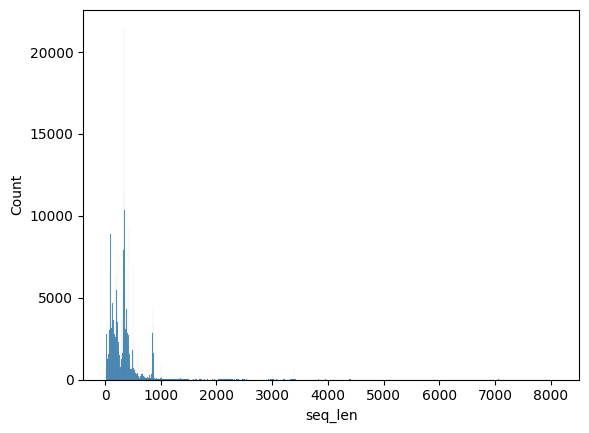

      start      end   count  percentage
0     11.00   685.75  263769   91.194449
1    685.75  1360.50   21585    7.462712
2   1360.50  2035.25     720    0.248930
3   2035.25  2710.00    1130    0.390682
4   2710.00  3384.75     932    0.322226
5   3384.75  4059.50     858    0.296642
6   4059.50  4734.25     106    0.036648
7   4734.25  5409.00       2    0.000691
8   5409.00  6083.75       2    0.000691
9   6083.75  6758.50      24    0.008298
10  6758.50  7433.25     108    0.037339
11  7433.25  8108.00       2    0.000691


In [27]:
print_seq_len_histogram(df, 12)

## Non - Lentivirus Viruses (Non-IDV)

In [41]:
virus_names = list(df["virus_name_genus"].unique())
print(f"Number of unique viruses = {len(virus_names)}")
virus_names

Number of unique viruses = 395


['Lentivirus',
 'Rotavirus',
 'Enterovirus',
 'Proboscivirus',
 'Orthohantavirus',
 'Gammacoronavirus',
 'Torbevirus',
 'Orthonairovirus',
 'Orthohepadnavirus',
 'Metapneumovirus',
 'Orthobunyavirus',
 'Norovirus',
 'Sapovirus',
 'Betacoronavirus',
 'Gammaretrovirus',
 'Betatorquevirus',
 'Paslahepevirus',
 'Hepacivirus',
 'Protoparvovirus',
 'Cytomegalovirus',
 'Muromegalovirus',
 'Parechovirus',
 'Orthoflavivirus',
 'Gammapapillomavirus',
 'Alphapapillomavirus',
 'Alphainfluenzavirus',
 'Betanodavirus',
 'Mastadenovirus',
 'Jeilongvirus',
 'Mammarenavirus',
 'Orthopoxvirus',
 'Alphavirus',
 'Orthopicobirnavirus',
 'Deltavirus',
 'Alphacoronavirus',
 'Orthopneumovirus',
 'Barthadenovirus',
 'Lagovirus',
 'Mobatvirus',
 'Morbillivirus',
 'Circovirus',
 'Henipavirus',
 'Rosavirus',
 'Capripoxvirus',
 'Amdoparvovirus',
 'Macropopoxvirus',
 'Porprismacovirus',
 'Drosmacovirus',
 'Bonzesmacovirus',
 'Bostasmacovirus',
 'Cosmacovirus',
 'Acamarivirus',
 'Gemygorvirus',
 'Gemycircularvirus',

In [43]:
non_idv_df = df[df["virus_name_genus"] != "Lentivirus"]
non_idv_df.shape

(65647, 13)

In [51]:
df[df["virus_name_genus"] == "Lentivirus"]["virus_name"].unique()

array(['Human immunodeficiency virus 1', 'Lentivirus',
       'Feline immunodeficiency virus', 'Simian immunodeficiency virus',
       'HIV-1 group M', 'Human immunodeficiency virus',
       'Human immunodeficiency virus 2', 'Small ruminant lentivirus',
       'Simian immunodeficiency virus SIV-mnd 2',
       'Equine infectious anemia virus',
       'Caprine arthritis encephalitis virus',
       'Simian-Human immunodeficiency virus', 'Visna-maedi virus',
       'Simian immunodeficiency virus - agm',
       'Ovine progressive pneumonia virus',
       'Brazilian caprine lentivirus',
       'Rabbit endogenous lentivirus type K',
       'Simian immunodeficiency virus - mac',
       'Simian immunodeficiency virus (ISOLATE GB1)',
       'Simian immunodeficiency virus - mnd',
       'Simian immunodeficiency virus (AGM155 ISOLATE)',
       'Simian immunodeficiency virus (AGM3 ISOLATE)',
       'Jembrana disease virus',
       'Simian immunodeficiency virus SIV-mnd 1',
       'Simian immunodefi

In [45]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq_non_idv.csv")
non_idv_df.to_csv(output_file_path, index=False)

In [46]:
non_idv_df = pd.read_csv(output_file_path)
non_idv_df.shape

(65647, 13)

In [47]:
column_stats(non_idv_df, "virus_name_genus").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/metadata/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq_non_idv_virus.csv"))

Number of unique values = 394
      virus_name_genus  virus_name_genus_count  virus_name_genus_percent
0          Hepacivirus                   12617                 19.219462
1    Orthohepadnavirus                   10267                 15.639709
2          Enterovirus                    2923                  4.452603
3            Rotavirus                    1861                  2.834859
4         Simplexvirus                    1851                  2.819626
..                 ...                     ...                       ...
389        Hemipivirus                       1                  0.001523
390        Pemapivirus                       1                  0.001523
391          Salovirus                       1                  0.001523
392        Bafinivirus                       1                  0.001523
393         Iridovirus                       1                  0.001523

[394 rows x 3 columns]


In [48]:
column_stats(non_idv_df, "virus_host_name").to_csv(os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/metadata/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq_non_idv_virus_host.csv"))

Number of unique values = 1248
              virus_host_name  virus_host_name_count  virus_host_name_percent
0                Homo sapiens                  42504                64.746295
1                  Sus scrofa                   2365                 3.602602
2               Gallus gallus                   1022                 1.556811
3                  Bos taurus                    820                 1.249105
4                 Felis catus                    545                 0.830198
...                       ...                    ...                      ...
1243    Hyphanturgus ocularis                      1                 0.001523
1244           Ardeola grayii                      1                 0.001523
1245        Petroica longipes                      1                 0.001523
1246  Notemigonus crysoleucas                      1                 0.001523
1247     Leucophaeus pipixcan                      1                 0.001523

[1248 rows x 3 columns]


min seq len = 11
max seq len = 8108


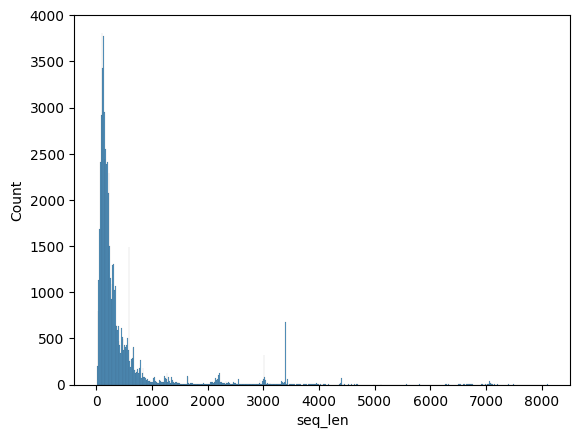

      start      end  count  percentage
0     11.00   685.75  58264   88.753485
1    685.75  1360.50   3506    5.340686
2   1360.50  2035.25    713    1.086112
3   2035.25  2710.00   1130    1.721328
4   2710.00  3384.75    932    1.419715
5   3384.75  4059.50    858    1.306990
6   4059.50  4734.25    106    0.161470
7   4734.25  5409.00      2    0.003047
8   5409.00  6083.75      2    0.003047
9   6083.75  6758.50     24    0.036559
10  6758.50  7433.25    108    0.164516
11  7433.25  8108.00      2    0.003047


In [49]:
print_seq_len_histogram(non_idv_df, 12)

**Number of host classes**

In [50]:
# 1% cutoff
filtered_df = filter_with_threshold_percentage(non_idv_df, "virus_host_name", 1)

Size of df = (65647, 13)
n= 65647
Number of unique values = 1248
              virus_host_name  virus_host_name_count  virus_host_name_percent
0                Homo sapiens                  42504                64.746295
1                  Sus scrofa                   2365                 3.602602
2               Gallus gallus                   1022                 1.556811
3                  Bos taurus                    820                 1.249105
4                 Felis catus                    545                 0.830198
...                       ...                    ...                      ...
1243    Hyphanturgus ocularis                      1                 0.001523
1244           Ardeola grayii                      1                 0.001523
1245        Petroica longipes                      1                 0.001523
1246  Notemigonus crysoleucas                      1                 0.001523
1247     Leucophaeus pipixcan                      1                 0.001523

In [61]:
column_stats(filtered_df, "virus_name_genus")

Number of unique values = 167
      virus_name_genus  virus_name_genus_count  virus_name_genus_percent
0          Hepacivirus                   12471                 26.698208
1    Orthohepadnavirus                   10182                 21.797863
2          Enterovirus                    2858                  6.118473
3            Rotavirus                    1601                  3.427458
4      Orthoflavivirus                    1569                  3.358952
..                 ...                     ...                       ...
162          Mimivirus                       1                  0.002141
163          Rosavirus                       1                  0.002141
164        Tobamovirus                       1                  0.002141
165         Avisivirus                       1                  0.002141
166  Orthomarburgvirus                       1                  0.002141

[167 rows x 3 columns]


,virus_name_genus,virus_name_genus_count,virus_name_genus_percent
0,Hepacivirus,12471,26.698208
1,Orthohepadnavirus,10182,21.797863
2,Enterovirus,2858,6.118473
3,Rotavirus,1601,3.427458
4,Orthoflavivirus,1569,3.358952
...,...,...,...
162,Mimivirus,1,0.002141
163,Rosavirus,1,0.002141
164,Tobamovirus,1,0.002141
165,Avisivirus,1,0.002141


min seq len = 11
max seq len = 7217


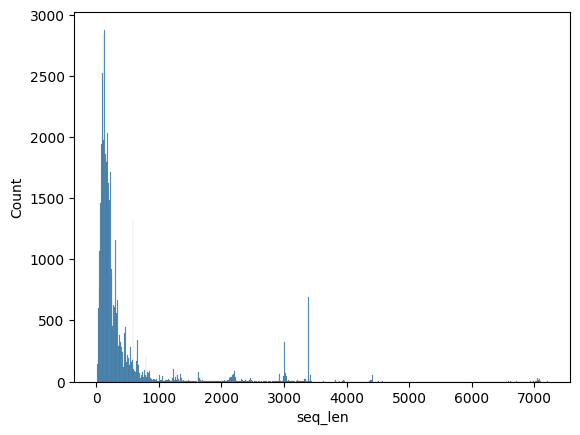

     start     end  count  percentage
0     11.0   611.5  40915   87.591788
1    611.5  1212.0   2428    5.197919
2   1212.0  1812.5    816    1.746912
3   1812.5  2413.0    640    1.370127
4   2413.0  3013.5    588    1.258804
5   3013.5  3614.0   1104    2.363469
6   3614.0  4214.5     34    0.072788
7   4214.5  4815.0     89    0.190533
8   4815.0  5415.5      1    0.002141
9   5415.5  6016.0      0    0.000000
10  6016.0  6616.5      3    0.006422
11  6616.5  7217.0     93    0.199097


In [52]:
print_seq_len_histogram(filtered_df, 12)

In [53]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq_non_idv_t0.01_c4.csv")
filtered_df.to_csv(output_file_path, index=False)

**Sequence Length Parameters**

In [55]:
np.percentile(filtered_df["seq_len"].values, [90, 95, 99])

array([ 714., 2161., 3392.])

min seq len = 11
max seq len = 7217


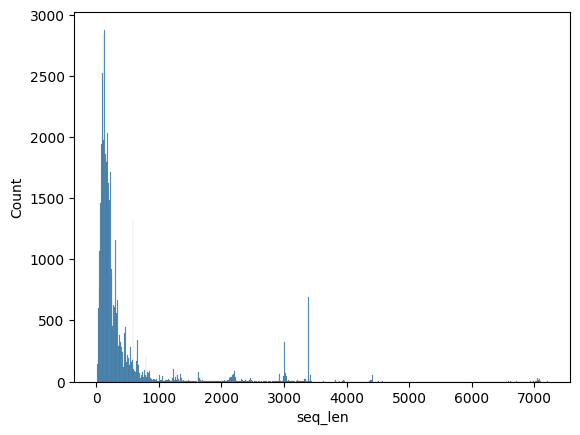

     start     end  count  percentage
0     11.0   611.5  40915   87.591788
1    611.5  1212.0   2428    5.197919
2   1212.0  1812.5    816    1.746912
3   1812.5  2413.0    640    1.370127
4   2413.0  3013.5    588    1.258804
5   3013.5  3614.0   1104    2.363469
6   3614.0  4214.5     34    0.072788
7   4214.5  4815.0     89    0.190533
8   4815.0  5415.5      1    0.002141
9   5415.5  6016.0      0    0.000000
10  6016.0  6616.5      3    0.006422
11  6616.5  7217.0     93    0.199097


In [56]:
print_seq_len_histogram(filtered_df, 12)

In [57]:
seq_len_filtered_df = filtered_df[filtered_df["seq_len"] <= 3392]
seq_len_filtered_df.shape

(46419, 13)

In [62]:
column_stats(seq_len_filtered_df, "virus_host_name")

Number of unique values = 4
  virus_host_name  virus_host_name_count  virus_host_name_percent
0    Homo sapiens                  42250                91.018764
1      Sus scrofa                   2348                 5.058274
2   Gallus gallus                   1003                 2.160753
3      Bos taurus                    818                 1.762209


,virus_host_name,virus_host_name_count,virus_host_name_percent
0,Homo sapiens,42250,91.018764
1,Sus scrofa,2348,5.058274
2,Gallus gallus,1003,2.160753
3,Bos taurus,818,1.762209


In [63]:
column_stats(seq_len_filtered_df, "virus_name_genus")

Number of unique values = 167
      virus_name_genus  virus_name_genus_count  virus_name_genus_percent
0          Hepacivirus                   12471                 26.866154
1    Orthohepadnavirus                   10182                 21.934984
2          Enterovirus                    2858                  6.156962
3            Rotavirus                    1601                  3.449019
4      Orthoflavivirus                    1497                  3.224973
..                 ...                     ...                       ...
162          Mimivirus                       1                  0.002154
163          Rosavirus                       1                  0.002154
164        Tobamovirus                       1                  0.002154
165         Avisivirus                       1                  0.002154
166  Orthomarburgvirus                       1                  0.002154

[167 rows x 3 columns]


,virus_name_genus,virus_name_genus_count,virus_name_genus_percent
0,Hepacivirus,12471,26.866154
1,Orthohepadnavirus,10182,21.934984
2,Enterovirus,2858,6.156962
3,Rotavirus,1601,3.449019
4,Orthoflavivirus,1497,3.224973
...,...,...,...
162,Mimivirus,1,0.002154
163,Rosavirus,1,0.002154
164,Tobamovirus,1,0.002154
165,Avisivirus,1,0.002154


In [65]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_virus_genus_species_virus_host_vertebrates_w_seq_non_idv_t0.01_c4_seq_len_in_99percentile.csv")
seq_len_filtered_df.to_csv(output_file_path, index=False)

### Dataset split on virus genus

In [72]:
genera = seq_len_filtered_df["virus_name_genus"].unique().tolist()
print(len(genera))

167


In [89]:
n = len(genera)
n_train = int(0.8 * n)
n_test = int(0.2 * n)
print(f"n_train={n_train}; n_test={n_test}")

n_train=133; n_test=33


In [90]:
genera_np = np.array(genera)
train_genera = np.random.choice(genera_np, size=n_train, replace=False)
print(len(train_genera))
train_genera
test_genera = list(set(genera) - set(train_genera))
print(len(test_genera))

133
34


In [92]:
train_df = seq_len_filtered_df[seq_len_filtered_df["virus_name_genus"].isin(train_genera)]
test_df = seq_len_filtered_df[seq_len_filtered_df["virus_name_genus"].isin(test_genera)]

In [97]:
train_df["virus_host_tax_id"].nunique()

4

In [98]:
test_df["virus_host_tax_id"].value_counts()

9606    7197
9823    1162
9031     207
9913      31
Name: virus_host_tax_id, dtype: int64

## Lentivirus (IDV)

In [66]:
idv_df = df[df["virus_name_genus"]=="Lentivirus"]
idv_df.shape

(223591, 11)

In [68]:
column_stats(idv_df, "virus_host_name")

Number of unique values = 52
                       virus_host_name  virus_host_name_count  \
0                         Homo sapiens                 221645   
1                       Macaca mulatta                    858   
2                          Felis catus                    143   
3                         Capra hircus                    129   
4                           Ovis aries                    124   
5                      Cercocebus atys                    123   
6                       Equus caballus                     95   
7                    Mandrillus sphinx                     59   
8               Cercopithecus aethiops                     36   
9                        Puma concolor                     25   
10                   Macaca nemestrina                     23   
11                 Macaca fascicularis                     21   
12              Mandrillus leucophaeus                     20   
13             Cercopithecus nictitans                     19

,virus_host_name,virus_host_name_count,virus_host_name_percent
0,Homo sapiens,221645,99.129661
1,Macaca mulatta,858,0.383736
2,Felis catus,143,0.063956
3,Capra hircus,129,0.057695
4,Ovis aries,124,0.055458
5,Cercocebus atys,123,0.055011
6,Equus caballus,95,0.042488
7,Mandrillus sphinx,59,0.026387
8,Cercopithecus aethiops,36,0.016101
9,Puma concolor,25,0.011181


In [15]:
output_file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "input/data/uniref90/20240131/uniref90_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_idv.csv")
# idv_df.to_csv(output_file_path, index=False)
idv_df = pd.read_csv(output_file_path)